In [62]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
def f(x):
    return 3*np.sin(x) + 4*x**2 + 7*x - 2 
def df(x):
    return 3*np.cos(x) + 8*x + 7

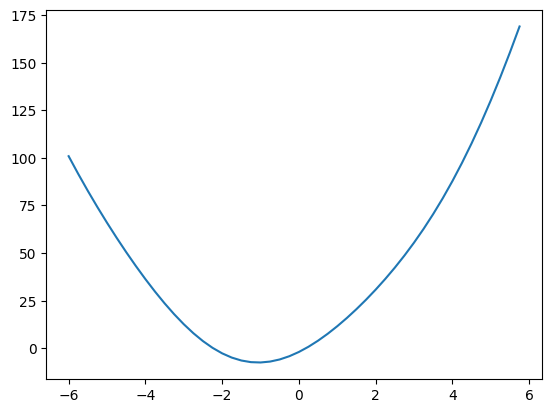

In [3]:
xs = np.arange(-6,6, 0.25)
ys = f(xs)
plt.plot(xs,ys)
dys1 = df(xs)

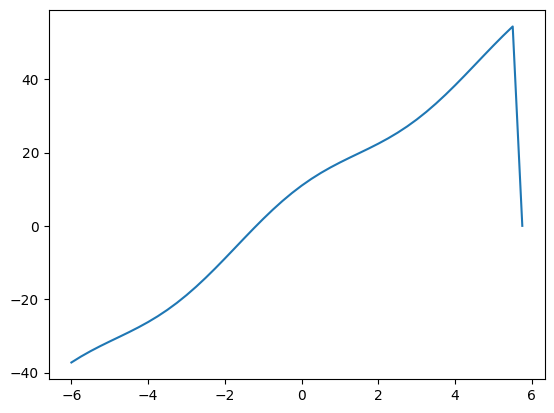

In [4]:
dys = np.zeros(len(xs))
for i in range(len(ys)-1):
    diff = ys[i+1]-ys[i]
    dys[i] = diff/0.25
plt.plot(xs,dys)

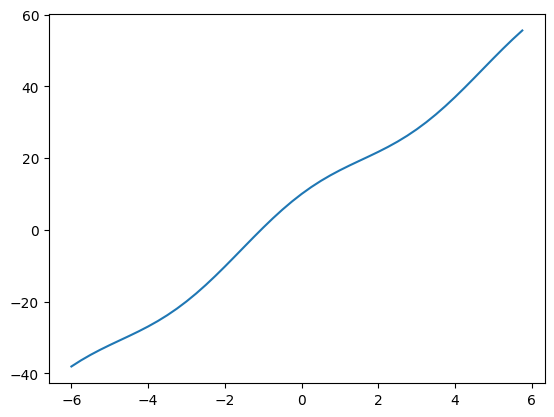

In [5]:
plt.plot(xs,dys1)

In [6]:
#for multivariate
def l(a,b,c):
    return a*b + c

h = 0.0001
a = 3
b = -4
c = 2.4

#wrt a
d_a = (l(a+h,b,c)-l(a,b,c))/h
#similarly
d_b = (l(a,b+h,c)-l(a,b,c))/h
d_c = (l(a,b,c+h)-l(a,b,c))/h

print(f"{l(a,b,c)} {d_a} {d_b} {d_c}")

-9.6 -4.000000000008441 3.000000000010772 0.9999999999976694


In [141]:
class Value:
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
        self.grad = 0
        
    def __repr__(self):
        return f"Value(data:{self.data})"
        
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data+other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
        
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data*other.data, (self,other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other):
        return self*other

    def __radd__(self, other):
        return self + other
        
    def __rsub__(self, other):
        return other + (-self)
        
    def __rtruediv__(self, other):
        return other * self**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
        
    def __neg__(self): 
        return self*-1

    def __sub__(self,other):
        return self + (-other)

    def __truediv__(self, other):
        return self * other**-1

    """
    def __pow__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        self = self if isinstance(self, Value) else Value(self)
        out = Value(self.data**other.data,(self,other),f'**{other}')

        def _backward():
            self.grad += other.data * (self.data**(other.data-1))*out.grad
            other.grad += (out.data*math.log(self.data))*out.grad

        out._backward = _backward
        return out
    """
    
    def __pow__(self,other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out


    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out                    


    def backward(self):
        self.grad = 1
        topo = []
        visited = set()
        
        def topSort(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    topSort(child)
                topo.append(v)
        topSort(self)

        for node in reversed(topo):
            node._backward()

class Activation:
    def tanh(self):
        e = (2*self).exp()
        out = (e-1)/(e+1)
        return out
    def sigmoid(self):
        e = (-self).exp()
        out = 1/(1+e)
        return out
        
h = 0.0001
a = Value(3); a.label='a'
b = Value(-4) ; b.label='b'
c = Value(2.4) ; c.label='c'
d = a*b ; d.label='d'
L = d + c; L.label='L'
print(L)

Value(data:-9.6)


### Insights from Manual Backpropagation

1. Use chain rule to determine the gradients(meaning how those variables affect the loss function).\
   so calculate dl/d{x_i}
2. Altering the variables in the direction of the respective gradients increases the loss function (optimization)\
   i.e., x_i = x_i + (d_xi)*f ; where f is some factor 

In [5]:
#Yes I copy pasted this, I don't want to learn a new library :')

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot



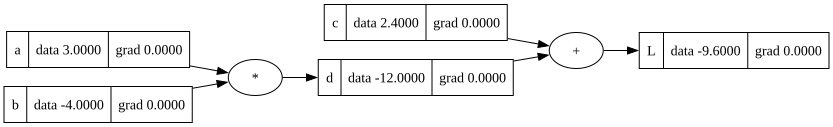

In [9]:
draw_dot(L)
#I didnt set the manual gradients

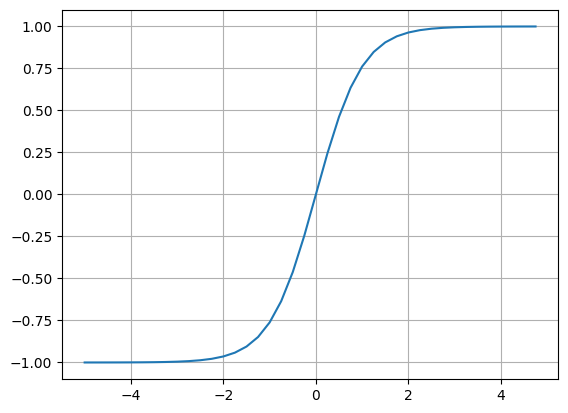

In [10]:
#activation function tanh(x)
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5,0.25)))
plt.grid()



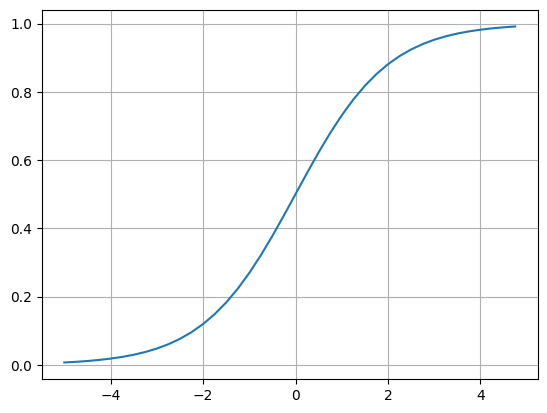

In [32]:
#activation function sigmoid(x)
plt.plot(np.arange(-5,5,0.25), 1/(1+np.exp(-(np.arange(-5,5,0.25)))))
plt.grid()
# 1/(1 + e^-x)

In [26]:
#inputs
x1 = Value(4, label='x1')
x2 = Value(2.3, label='x2')

#weights
w1 = Value(-1.2, label='w1')
w2 = Value(0, label='w2')

#bias
b = Value(3, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

xw = x1w1 + x2w2; xw.label =  'x1*w1 + x2*w2'
n = xw + b; n.label = 'n'
o = n.tanh() ; o.label = 'o'

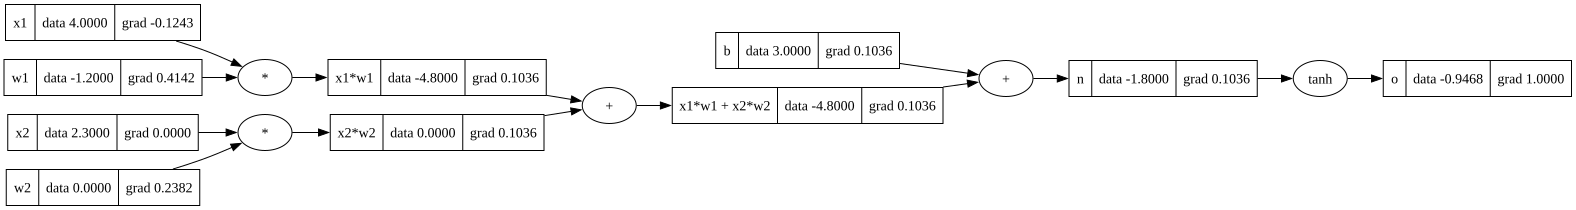

In [30]:
draw_dot(o)

In [42]:
## Manual gradient assignment
#do/dn = 1 - o**2 ( d(tanh(x)) = 1- tanh^2(x))
#x.grad = do/dx (partial)
o.grad = 1
n.grad = 0.104
xw.grad = n.grad
b.grad = n.grad

x2w2.grad = xw.grad
x1w1.grad = xw.grad

w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data

In [31]:
1 - o.data**2

0.10355837403815227

In [28]:
## Doing backprop manually by function

o._backward()
n._backward()
xw._backward()
x1w1._backward()
x2w2._backward()


In [29]:
o.backward()

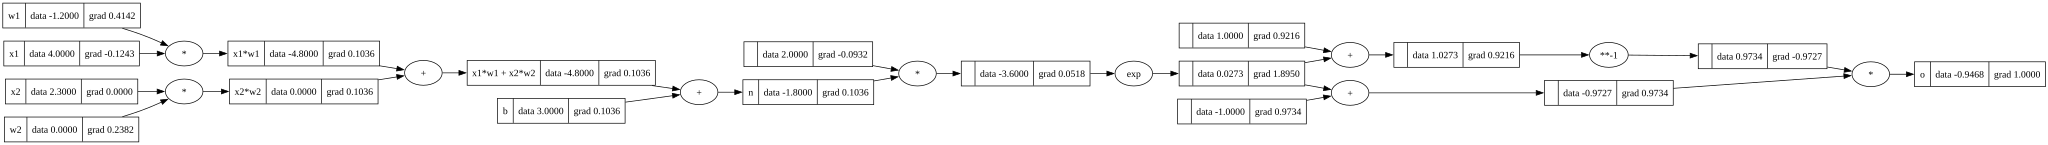

In [34]:
#inputs
x1 = Value(4, label='x1')
x2 = Value(2.3, label='x2')

#weights
w1 = Value(-1.2, label='w1')
w2 = Value(0, label='w2')

#bias
b = Value(3, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

xw = x1w1 + x2w2; xw.label =  'x1*w1 + x2*w2'
n = xw + b; n.label = 'n'

o = Activation.tanh(n)

o.label = 'o'
o.backward()

draw_dot(o)


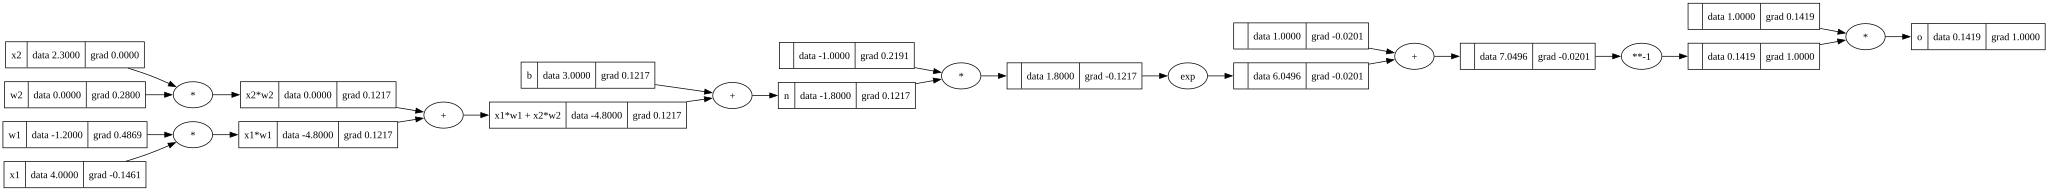

In [51]:
#inputs
x1 = Value(4, label='x1')
x2 = Value(2.3, label='x2')

#weights
w1 = Value(-1.2, label='w1')
w2 = Value(0, label='w2')

#bias
b = Value(3, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

xw = x1w1 + x2w2; xw.label =  'x1*w1 + x2*w2'
n = xw + b; n.label = 'n'

o = Activation.sigmoid(n)

o.label = 'o'
o.backward()

draw_dot(o)


In [55]:
#with pytorch
import torch

x1 = torch.Tensor([4.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([2.3]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-1.2]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([0.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([3.0]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.sigmoid(n)


print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())



0.1418510416824603
---
x2 0.0
w2 0.2799774386044343
x1 -0.14607519419177992
w1 0.4869172946242448


In [162]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((xi*wi for xi, wi in zip(x, self.w)), self.b)
        out = act.tanh()
        return out
        
    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self, x):
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        params = []
        for p in self.neurons:
            ps = p.parameters()
            params.extend(ps)
        return params
        
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(sz)-1)]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for p in self.layers:
            ps = p.parameters()
            params.extend(ps)
        return params

    def flush_grad(self):
        for x in self.parameters():
            x.grad = 0

In [172]:
nn = MLP(3,[4,3,1])
out = nn(x)
print(out)
nn.parameters()

Value(data:-0.7502070218903841)


[Value(data:0.7539177512433668),
 Value(data:0.6455886932775445),
 Value(data:0.8243842108663197),
 Value(data:0.6959881648913038),
 Value(data:0.9446319890359149),
 Value(data:0.6088477686613916),
 Value(data:-0.11372121516731659),
 Value(data:0.6196643414827803),
 Value(data:-0.7570028178690251),
 Value(data:-0.8394991877372397),
 Value(data:-0.9650548698804029),
 Value(data:0.018652377359606565),
 Value(data:-0.9619861173168336),
 Value(data:0.21025658614420295),
 Value(data:-0.47381402725709054),
 Value(data:0.3129386459976),
 Value(data:0.7993622383791994),
 Value(data:-0.18969295356910343),
 Value(data:0.9769357929600369),
 Value(data:0.5225308016424917),
 Value(data:0.9044683627264394),
 Value(data:0.16760821171184315),
 Value(data:-0.9566204863676295),
 Value(data:-0.7869877743325417),
 Value(data:0.9428570783297427),
 Value(data:0.8215001514711138),
 Value(data:-0.2464291767592366),
 Value(data:-0.9372105026917505),
 Value(data:0.13875197982756626),
 Value(data:0.7226217015533

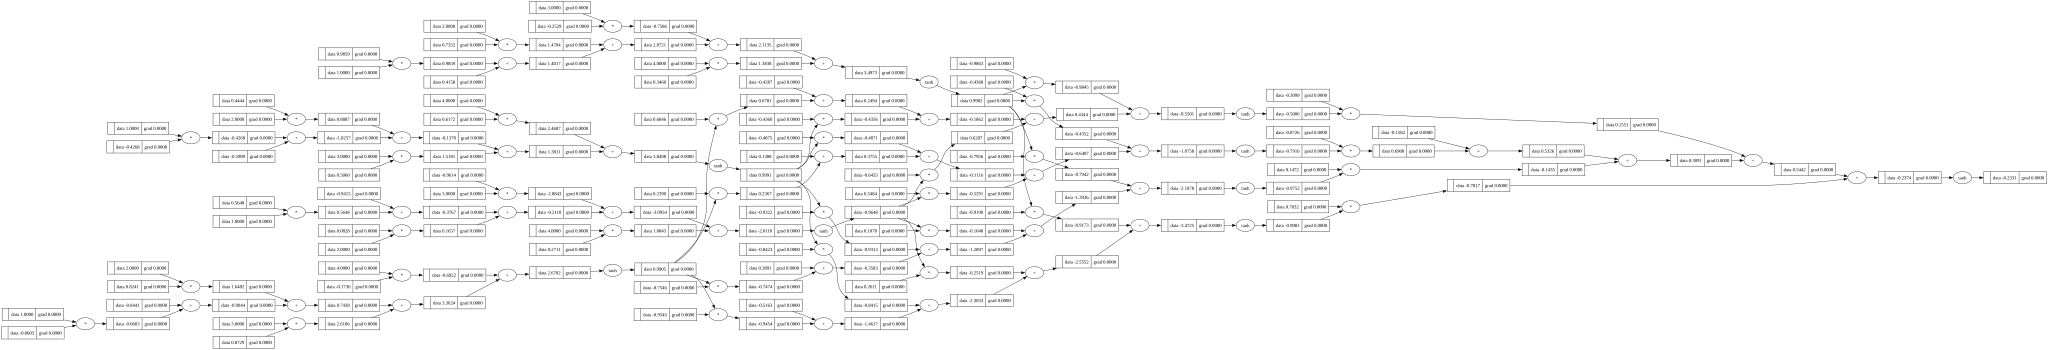

In [96]:
draw_dot(out)

In [173]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] 

In [180]:
for fp in range(200):
    #forward pass
    ypred = [nn(x) for x in xs]
    
    # sumation((yi_actual - yi_pred))**2
    loss = sum((yia - yip)**2 for yia, yip in zip(ys,ypred))
    nn.flush_grad()
    loss.backward()

    #update params
    for p in nn.parameters():
        p.data += -(p.grad * 0.19)

    print(f"{fp} : {loss}")
    

0 : Value(data:0.0010157050002483352)
1 : Value(data:0.0010101616691733154)
2 : Value(data:0.0010046778309254945)
3 : Value(data:0.0009992525373739127)
4 : Value(data:0.0009938848603753677)
5 : Value(data:0.000988573891251331)
6 : Value(data:0.000983318740281239)
7 : Value(data:0.000978118536211462)
8 : Value(data:0.0009729724257794598)
9 : Value(data:0.0009678795732525566)
10 : Value(data:0.0009628391599808509)
11 : Value(data:0.0009578503839636299)
12 : Value(data:0.0009529124594290243)
13 : Value(data:0.0009480246164262338)
14 : Value(data:0.0009431861004300014)
15 : Value(data:0.0009383961719569014)
16 : Value(data:0.0009336541061929533)
17 : Value(data:0.0009289591926322917)
18 : Value(data:0.0009243107347264456)
19 : Value(data:0.0009197080495438176)
20 : Value(data:0.0009151504674391163)
21 : Value(data:0.00091063733173236)
22 : Value(data:0.0009061679983971499)
23 : Value(data:0.0009017418357578017)
24 : Value(data:0.0008973582241952057)
25 : Value(data:0.0008930165558610689)
2

In [181]:
ypred

[Value(data:0.9884482005100048),
 Value(data:-0.989949538774053),
 Value(data:-0.9892972679640997),
 Value(data:0.988414037729868)]